In [218]:
import numpy as np
import qutip as qt
import scipy.linalg as LA
import scipy.sparse as sp
import scipy.sparse.linalg as spla
# from numpy import linalg as LA
import matplotlib.pyplot as plt
from scipy.integrate import quad_vec
from scipy.linalg import expm
import os
import pickle
from sympy import *
import matplotlib.cm as cm
from scipy.optimize import root
from cmath import *
# rc( 'font' , **{ 'family':  'serif ’ , ’ serif ’:[ ’Palatino ’]})


In [127]:
def ensure_directory_exists(home):
    if not os.path.exists(home):
        os.makedirs(home)

In [12]:
# OBC/PBC approach ( Liapunov equation)

#Ground state of SSH Hamiltonian in position base 

def Hamiltonian_SSH(L, t1, t2, Type):
    unit_cells = L
    # Define the submatrices
    S = np.array([[0,  t1], 
                  [ t1 , 0]])
    
    T = np.array([[0, 0], [ t2, 0]])

    # Create sparse diagonal matrices   
    
    TN_up = np.eye(unit , k=1)
    TN_down = np.eye(unit , k=-1)
    IN = np.eye(unit )

    # Use kron (Kronecker product) to create the tensor products
    IN_S = np.kron(IN, S)
    TN_T_up = np.kron(TN_up, T)
    TN_T_down = np.kron(TN_down, T.T)


    # Assemble the Hamiltonian
    # o= OBC
    if Type == 0:
        H = IN_S + TN_T_up + TN_T_down
    # PBC condition
    else:
        H= IN_S + TN_T_up + TN_T_down
        H[2*unit-2:,:2]= T
        H[:2,2*unit-2:]= T.T
        
    
#      # Calculate eigenvalues and eigenvectors for the OBC/OBC damping matrix
    EIGen, EIGv = np.linalg.eig(H)
    

    return EIGen, EIGv, H




In [225]:
# Library check

A = np.array([[1., 2.],
              [3., 4.]])

w, v = np.linalg.eig(A)
print(w)
print(v)


[-0.37228132  5.37228132]
[[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [4]:
# Von Neuman Entropy ( avoid computing log(0) )
def xlogx(x):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    mask = x > 0
    out[mask] = -x[mask] * np.log(x[mask]) -(1-x[mask]) * np.log(1-x[mask])
    return out

In [5]:
def Bipartite_EE(rho_0, H, T):
    N= rho_0.shape[0]//2
    U_conj= LA.expm(1j*H.T*T)
    U_T= LA.expm(-1j*H.T*T)
    rho_t= U_conj@rho_0@U_T
    #Right side
    EIGen, _ = LA.eig(rho_t[N:,N:])
    #Left side
    EIGen, _ = LA.eig(rho_t[:N,:N])
    rho_log_rho = np.sum(xlogx(EIGen))
    return np.real(rho_log_rho)

In [6]:

def GroundState_CovarianceMatrix(l, t1, t2,  Type, tolerance=1e-9):
    """
    Compute the sum of projectors for the ground state eigenvectors corresponding to negative eigenvalues.
    (chemical potential= 0)
    Parameters:
        Hamiltonian: Function to compute the Hamiltonian and its eigenvalues and eigenvectors
        L, T1, M, T2, Phi, TYPE: Parameters for the Hamiltonian function
        tolerance: Tolerance for considering eigenvalues as degenerate
    
    Returns:
        GS_rho: Sum of projectors matrix (ground state covariance matrix)
        is_projector: Boolean indicating if GS_rho is a projector
    """
    # Extract eigenvalues and eigenvectors from the Hamiltonian
    eigEn, eigV, H = Hamiltonian_SSH(l, t1, t2, Type)

    # Filter eigenvectors with negative eigenvalues
    GS = eigV[:, eigEn < 0]

    # Normalize each eigenvector
    GS_normalized = np.array([vec / np.linalg.norm(vec) for vec in GS.T]).T

    # Degenerate eigenvalue handling
    negative_indices = [i for i, val in enumerate(eigEn) if val < 0]  # indices with negative eigenvalues
    degenerate_groups = {}
    for i in negative_indices:
        for j in negative_indices:
            if i != j and abs(eigEn[i] - eigEn[j]) < tolerance:
                if i in degenerate_groups:
                    degenerate_groups[i].add(j)
                else:
                    degenerate_groups[i] = {i, j}

    # Orthogonalize degenerate eigenvectors
    for indices in degenerate_groups.values():
        actual_indices = [negative_indices.index(idx) for idx in indices]  # get actual positions in GS_normalized
        degenerate_eigvecs = GS_normalized[:, actual_indices]
        Q, _ = np.linalg.qr(degenerate_eigvecs)
        GS_normalized[:, actual_indices] = Q

    # Compute the sum of projectors
    GS_rho = np.sum([np.outer(vec, vec.conj()) for vec in GS_normalized.T], axis=0)

    # Check if GS_rho is a projector
    G_rho_squared = np.dot(GS_rho, GS_rho)
    is_projector = np.allclose(G_rho_squared, GS_rho, atol=1e-9)

    return GS_rho, is_projector

In [43]:
#Inhomogeneous initial state

def Gamma_0(L, t1, t2,  Type):
    '''
    Compute the initial inhomogeneous state
    |0>= |0>_L x|GS>_R
    |GS>_R := ground state of a ssh chain with N/2 sites
    |0>_L= \Pi_{i=-N/2}^{0} |0>
'''
    HalfS_unit= L
    n1= np.array([[0,0],[0,1]])
    rho_0L= np.zeros([4*HalfS_unit,4*HalfS_unit]) #Left side is the vacuum
    
    gs_indices,_= GroundState_CovarianceMatrix(L, t1, t2,  Type)
    rho_0R= np.kron(n1,gs_indices) # Right side is the Ground State
    rho_0= rho_0L +rho_0R
    return rho_0


In [217]:
# Unitary evolution of covariance matrix
def Gamma_t(rho_0, H, T):
    U_conj= expm(1j*H.T*T)
    U_T= expm(-1j*H.T*T)
    rho_t= U_conj@rho_0@U_T
    return rho_t

def Gamma_t_sparse(rho_0,H,T):
    rho_0=sp.csr_matrix(rho_0)
    H= sp.csr_matrix(H)
    rho_t=spla.expm_multiply(H * T, rho_0)
    return rho_t

In [70]:

import matplotlib.pyplot as plt

def plot_density_heatmap(GAMMA, t_axis=None, cmap="coolwarm",
                         vmin=0.0, vmax=1.0, cbar_label=r"$n(x,t)=C_{x,x}(t)$",
                         yticks=None):
    """
    Plot heatmap of n(x,t) = C_{x,x}(t).

    GAMMA : array of shape (T, N, N)  OR  (T, N*N) with row-stacking (index = j + i*N)
    t_axis: optional 1D array of length T for labeling the time axis
    cmap  : matplotlib colormap
    vmin, vmax: color scale limits
    cbar_label: colorbar label
    yticks: optional tick locations for time axis (only used if t_axis is given)
    """
    GAMMA = np.asarray(GAMMA)
    if GAMMA.ndim != 3 :
        raise ValueError("GAMMA must have shape (T,N,N) or (T,N*N,1).")

    T = GAMMA.shape[0]
    _, N, N2 = GAMMA.shape
    # Extract n(x,t) depending on the input format
    if GAMMA.ndim == 3:
        if N2==1:
            # (T, N*N, 1) row-stacked -> take indices i*(N+1)
            TN = GAMMA.shape[1]
            N = int(np.sqrt(TN))
            if N*N != TN:
                raise ValueError("For (T,N*N) input, second dim must be a perfect square.")
            diag_idx = np.arange(0, N*(N+1), N+1)  # i*(N+1)
            n_xt = GAMMA[:, diag_idx]  # (T,N)
       
        if N == N2:
            n_xt = np.diagonal(GAMMA, axis1=1, axis2=2)  # (T,N)

    n_xt = np.real_if_close(n_xt)

    fig, ax = plt.subplots(figsize=(9, 6))

    if t_axis is None:
        im = ax.imshow(n_xt, origin="lower", aspect="auto",
                       vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlabel("position $x$")
        ax.set_ylabel("time index")
    else:
        t_axis = np.asarray(t_axis)
        if t_axis.shape[0] != T:
            raise ValueError("t_axis must have length T = GAMMA.shape[0].")
        im = ax.imshow(n_xt, origin="lower", aspect="auto",
                       extent=[0, N-1, t_axis[0], t_axis[-1]],
                       vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlabel("$x$")
        ax.set_ylabel("$t$")
        if yticks is not None:
            ax.set_yticks(yticks)
            ax.set_yticklabels([f"{val/np.pi:.2f}" for val in yticks])

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, labelpad=15)

    plt.tight_layout()
    return fig, ax



In [244]:
#test
L= 100
T1=1
T2=0.5
B_C= 0
#Quench Hopping rates
T1_q=0
T2_q=1

_,_,H= Hamiltonian_SSH(2*L, T1_q, T2_q, B_C)
#inhomogeneous initial state
rho_0= Gamma_0(L,T1,T2,B_C)

home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"

In [245]:
#dynamics
t= np.arange(0,20*np.pi,1)
t_zeta= 20*np.pi
gamma_t = np.array([Gamma_t(rho_0, H, step) for step in t ])
ee_t= np.array([Bipartite_EE(rho_0,H,step) for step in t])
gamma_t_zeta = Gamma_t(rho_0,H,t_zeta)

print(f'done, system size {4*L}')

<ipython-input-4-aab72e677fdc>:6: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = -x[mask] * np.log(x[mask]) -(1-x[mask]) * np.log(1-x[mask])


done, system size 400


(0.5, 2.0)

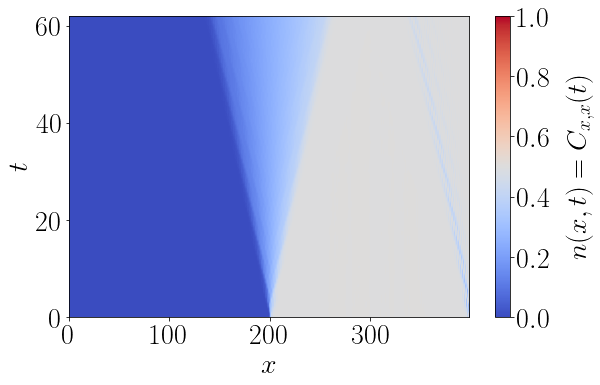

In [241]:
#Heat Plot


fig, ax = plot_density_heatmap(gamma_t, t_axis=t, cmap="coolwarm")
# Set global font size and LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})
# ax.set_ylim(0,50*np.pi)
# Save the figure as PDF  
plt.savefig(home_data + f"TOPO_Transport_{size}_J1ovJ2_{T1/T2}_J1ovJ2_{T1_q/T2_q}.png", format='png', bbox_inches='tight', dpi=300)
T1/T2,T1_q/T2_q

(400,)


(0.5, 2.0)

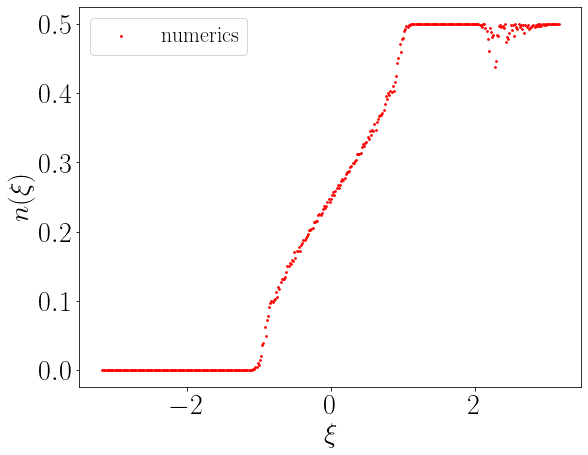

In [242]:
# Re-scaled Local observable 
size= 2*L
position = np.arange(-size,size)
zeta= position/t_zeta # rescaled ray

Gamma_t_zeta_D= np.diag(gamma_t_zeta)

print(Gamma_t_zeta_D.shape)
fig, axes = plt.subplots(1, 1, figsize=(9, 7))
axes.scatter(zeta,Gamma_t_zeta_D, s=3, c='r', label='numerics')
axes.set_xlabel(r'$ \xi $')
axes.set_ylabel(r'$n(\xi)$')
n= np.arange(-3,3,0.1)
# N= n_zeta(n)
# axes.plot(n,N, c='black', label='GH')
axes.legend(fontsize=22)
plt.savefig(home_data + f"n_GHD_{size}_TOPO_Transport_{size}_J1ovJ2_{T1/T2}_J1ovJ2_{T1_q/T2_q}.png", format='png', bbox_inches='tight', dpi=300)
T1/T2, T1_q/T2_q

0.5

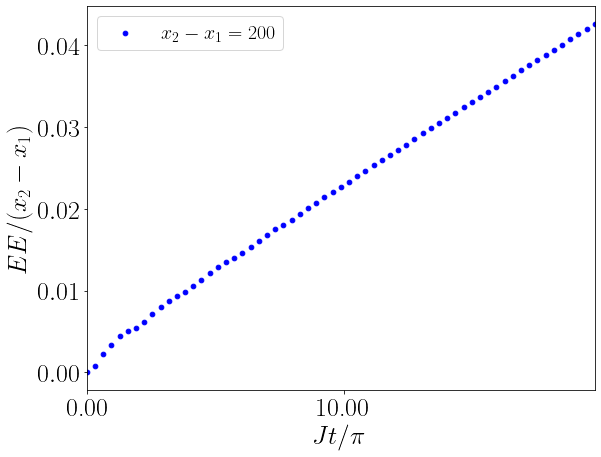

In [243]:
# Create a larger figure and adjust the layout
fig, axes = plt.subplots(1, 1, figsize=(9, 7))

# Plot the real part of the eigenvalues
axes.scatter(t, ee_t/(2*L),c='b',label=f"$x_2-x_1={2*L}$",s=22)
# axes.plot(t_solid, EE, c='black', label='GHD prediction')
axes.set_xlabel('$Jt/\pi$', fontsize=26)
axes.set_ylabel('$EE/(x_2-x_1)$', fontsize=26)
axes.tick_params(axis='both', which='major', labelsize=26)
xticks = [0, 10*np.pi, 20*np.pi]

# Set the x-ticks
axes.set_xticks(xticks)
axes.set_xticklabels([f'{val/np.pi:.2f}' for val in xticks])
axes.set_xlim(min(t), max(t))
axes.legend(fontsize=20)
plt.tight_layout()

# Set global font size and LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 38,
})


ensure_directory_exists(home_data)
# Save the figure as PDF  
plt.savefig(home_data + f"EE_GHD_size_{size}_l_{2*L}_TOPO_Transport_{size}_J1ovJ2_{T1/T2}_J1ovJ2_{T1_q/T2_q}.png", format='png', bbox_inches='tight', dpi=300)
T1/T2

Number of eigenvalues: 256


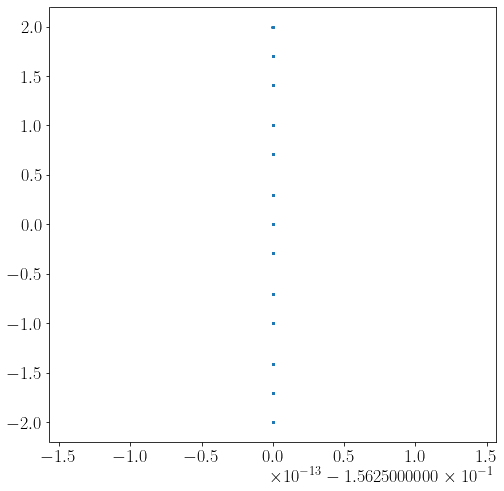

In [255]:
def C_block(k1, k2, N, gamma):
    L = 2 * N

    # Include the missing i prefactor
    prefac = 1j  # or -2j*J if you want physical units

    # L part
    Lmat = prefac * np.array([
        [ np.cos(k1) - np.cos(k2), 0, 0, 0],
        [0, -np.cos(k1) - np.cos(k2), 0, 0],
        [0, 0,  np.cos(k1) + np.cos(k2), 0],
        [0, 0, 0, -np.cos(k1) + np.cos(k2)]
    ], dtype=complex)

    # Helpers
    phaseP = np.exp(1j * (N - 1) * np.pi / 2)
    phaseM = np.conj(phaseP)
    s = np.sin(N * np.pi / 2)
    s2 = s**2

    # M matrix
    M = (1 / L**2) * np.array([
        [ 2,
          (1 + (-1)**N) * phaseP * s,
          (1 + (-1)**N) * phaseP * s,
          -2 * s2 ],
        [ (1 + (-1)**N) * phaseM * s,
          2,
          2 * ((-1)**N) * s2,
          (1 + (-1)**N) * phaseP * s ],
        [ (1 + (-1)**N) * phaseM * s,
          2 * ((-1)**N) * s2,
          2,
          (1 + (-1)**N) * phaseP * s ],
        [ -2 * s2,
          (1 + (-1)**N) * phaseM * s,
          (1 + (-1)**N) * phaseM * s,
          2 ]
    ], dtype=complex)

    return Lmat - gamma * M


def spectrum_all(N, gamma):
    L = 2 * N
    ks = 2 * np.pi * np.arange(L) / L
    evals = []

    for k1 in ks:
        for k2 in ks:
            C = C_block(k1, k2, N, gamma)
            w, _ = np.linalg.eig(C)
            evals.extend(w)

    return np.array(evals, dtype=complex)


# Example usage
N = 4
gamma = 5
vals = spectrum_all(N, gamma)

# ✅ Get the total number of eigenvalues
print("Number of eigenvalues:", len(vals))  # should be 4 * (2N)^2

# Plot
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
})
plt.figure(figsize=(8,8))
plt.plot(np.real(vals), np.imag(vals), 'o', markersize=2)

# plt.xlabel('$Re(\lambda)$')
# plt.ylabel('$Im(\lambda)$')
# plt.gca().set_aspect('equal', 'box')
# plt.tight_layout()
